Esse Notebook será responsável por mostrar TODO meu passo a passo de evolução da acurácia, loss, quantas épocas e outras coisas 

# Primeiro teste foi feito com essa estrutura:

## Parâmetros utilizados

| Parâmetro | Valor |
|---|---:|
| Arquitetura | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 |
| Função de ativação | ReLU |
| Ativação da saída | Softmax |
| Função de erro | Cross-entropy loss |
| Otimizador | SGD |
| Learning rate | 0.1 |
| Batch size | 64 |
| Épocas | 10 |
| Seed | 42 |

## Interpretação da arquitetura

Cada imagem do MNIST possui 28 × 28 pixels. Após o reshape, cada imagem
é transformada em um vetor com 784 valores.

A arquitetura escolhida foi:

```text
784 entradas
    ↓
128 neurônios na primeira camada oculta
    ↓
64 neurônios na segunda camada oculta
    ↓
10 probabilidades de saída

```

As 10 saídas representam os dígitos possíveis entre 0 e 9.

## Resultados registrados

Os valores abaixo foram obtidos durante o treinamento do modelo
baseline.

Para cada época, foram armazenadas três informações:

- **Loss:** mede o tamanho do erro do modelo.
- **Acurácia de treino:** mede o desempenho nas imagens utilizadas
  durante o aprendizado.
- **Acurácia de teste:** mede o desempenho em imagens que não foram
  utilizadas para atualizar os pesos.

A acurácia de teste é especialmente importante porque mostra a
capacidade de generalização da rede neural.

In [12]:
import matplotlib.pyplot as plt

epocas = [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]

loss = [
    0.3300,
    0.1486,
    0.1068,
    0.0833,
    0.0680,
    0.0566,
    0.0472,
    0.0405,
    0.0340,
    0.0286
]

acuracia_treino = [
    94.43,
    96.23,
    97.43,
    98.02,
    98.34,
    98.61,
    98.79,
    98.47,
    99.13,
    99.52
]

acuracia_teste = [
    94.43,
    95.60,
    96.70,
    97.37,
    97.48,
    97.50,
    97.59,
    97.05,
    97.75,
    97.94
]

## Gráfico da Acurácia 

Nessa célula foi feito o gráfico de linha para entendermos como foi a evolução por época do primeiro teste e treino. Para termos uma noção, esse teste demorou 21 segundos. Depois vamos usar esse tempo e a acurácia para entendermos mais

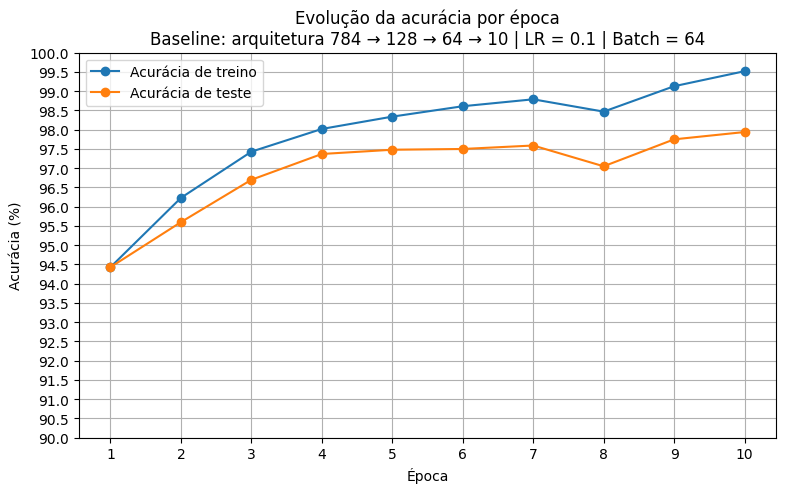

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    acuracia_treino,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas,
    acuracia_teste,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Baseline: arquitetura 784 → 128 → 64 → 10 | LR = 0.1 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(epocas)

plt.ylim(90, 100)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/baseline_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Gráfico de Loss

Aqui vamos mostrar a taxa de erro do nosso projeto e da primeira medição. Como é possível ver, deu uma bela despencada da primeira para a segunda época e depois vai estabilizando. Temos que diminuir mais essa linha e esse erro. Um jeito que vejo para isso é aumentarmos ou diminuirmos a taxa de aprendizado, que será nosso próximo passo.

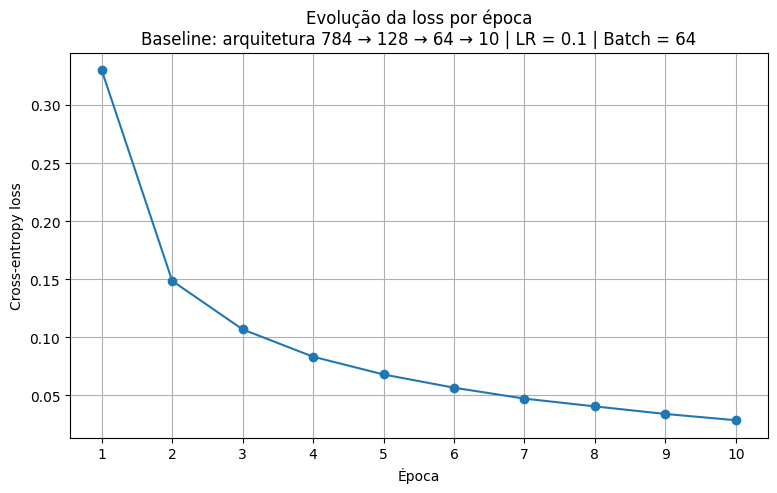

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    loss,
    marker="o"
)

plt.title(
    "Evolução da loss por época\n"
    "Baseline: arquitetura 784 → 128 → 64 → 10 | LR = 0.1 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(epocas)

plt.grid(True)

plt.savefig(
    "../results/baseline_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 1

O modelo baseline apresentou uma evolução consistente durante o
treinamento.

A loss caiu de **0,3300** na primeira época para **0,0286** na décima
época. Isso indica que os ajustes realizados pelo SGD permitiram à rede
produzir previsões progressivamente mais próximas das respostas
corretas.

A acurácia de teste começou em **94,43%** e terminou em **97,94%**,
representando uma melhoria de **3,51 pontos percentuais**.

A maior acurácia de teste foi registrada na décima época: 97,94%

Houve também umas oscilações na oitava época: 
Época 7 → 97,59%
Época 8 → 97,05%
Época 9 → 97,75%

Isso é normal.


Os primeiros parâmetros foram colocados totalmente aleatórios. Para primeira vez, foi muito satisfatório. Mesmo passando de 92% de acurácia, quero deixar melhor e mais completo, tanto minha análise e testes como meu código e meu projeto. Como dito agora pouco, o primeiro parâmetro que vamos mexer é o de aprendizado.

## Segundo teste foi feito com essa estrutura:

A única alteração foi o aumento de épocas e mudando a taxa de aprendizado de 0.1 para 0.08:

| Parâmetro | Primeiro teste | Segundo teste |
|---|---:|---:|
| Arquitetura | 784 → 128 → 64 → 10 | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 | 2 |
| Função de ativação | ReLU | ReLU |
| Ativação da saída | Softmax | Softmax |
| Função de erro | Cross-entropy loss | Cross-entropy loss |
| Otimizador | SGD | SGD |
| Learning rate | 0.10 | 0.07 |
| Batch size | 64 | 64 |
| Épocas | 10 | 30 |
| Seed | 42 | 42 |
| Tempo de treinamento | 21 segundos | 1 minuto e 8 segundos |


Ganho percentual foi bem pequena: 
98,08% - 97,94% = 0,14 ponto percentual

Mas o Loss caiu demais:
0,0286 → 0,0029

Ao mesmo tempo, a acurácia de treino chegou a 100%, mas o teste ficou no máximo 98,04%. Isso sugere um começo de overfitting leve. Não é um problema grave, mas mostra que continuar aumentando épocas provavelmente trará pouco ganho real.

In [15]:
epocas_teste_2 = list(range(1, 31))

loss_teste_2 = [
    0.3667,
    0.1749,
    0.1281,
    0.1007,
    0.0833,
    0.0697,
    0.0598,
    0.0522,
    0.0448,
    0.0396,
    0.0347,
    0.0300,
    0.0264,
    0.0227,
    0.0197,
    0.0175,
    0.0146,
    0.0124,
    0.0113,
    0.0100,
    0.0085,
    0.0074,
    0.0066,
    0.0054,
    0.0047,
    0.0045,
    0.0039,
    0.0036,
    0.0031,
    0.0029
]

acuracia_treino_teste_2 = [
    93.72,
    95.26,
    96.89,
    97.57,
    97.95,
    98.21,
    98.42,
    98.58,
    98.87,
    99.23,
    99.29,
    99.37,
    99.29,
    99.13,
    99.49,
    99.60,
    99.83,
    99.68,
    99.53,
    99.80,
    99.94,
    99.88,
    99.97,
    99.98,
    99.99,
    99.99,
    100.00,
    99.99,
    99.99,
    100.00
]

acuracia_teste_teste_2 = [
    93.81,
    95.01,
    96.44,
    96.92,
    97.07,
    97.21,
    97.36,
    97.32,
    97.62,
    97.84,
    97.79,
    97.69,
    97.43,
    97.23,
    97.78,
    97.74,
    97.91,
    97.76,
    97.43,
    98.04,
    97.86,
    97.89,
    97.94,
    98.03,
    98.08,
    98.02,
    97.97,
    98.05,
    98.06,
    98.04
]

## Gráfico da acurácia

O gráfico mostra a evolução da acurácia de treino e de teste ao longo
das 30 épocas.

A acurácia de teste começou em **93,81%** e atingiu seu melhor valor na
época 25:

```text
98,08%
```

Depois disso, a acurácia permaneceu próxima desse valor, com pequenas
oscilações.

A acurácia de treino chegou a 100,00%, enquanto a acurácia de teste
ficou próxima de 98,00%.

Isso indica que a rede continuou aprendendo muito bem os dados de
treino, mas os ganhos nas imagens de teste ficaram menores após certo
ponto.

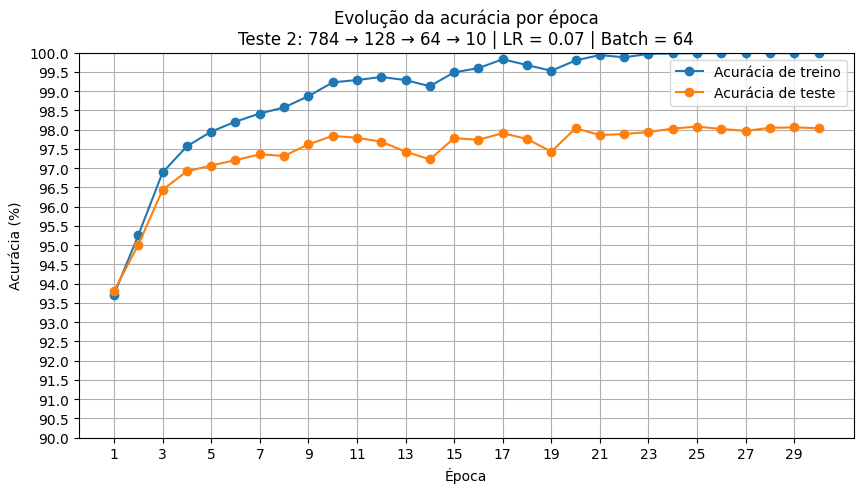

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_2,
    acuracia_treino_teste_2,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas_teste_2,
    acuracia_teste_teste_2,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Teste 2: 784 → 128 → 64 → 10 | LR = 0.07 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    90,
    100
)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/teste_2_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

# Gráfico de loss

A loss caiu de **0,3667** na primeira época para **0,0029** na trigésima
época.

A queda foi mais intensa nas primeiras épocas e ficou mais gradual ao
longo do treinamento.

Esse comportamento mostra que a rede aprendeu rapidamente os padrões
mais importantes e depois passou a realizar ajustes menores.

Mesmo quando a acurácia de teste começou a oscilar perto de 98%, a loss
continuou diminuindo. Isso mostra que o modelo ficou mais confiante nas
respostas corretas, mesmo sem aumentar muito a quantidade total de
acertos.

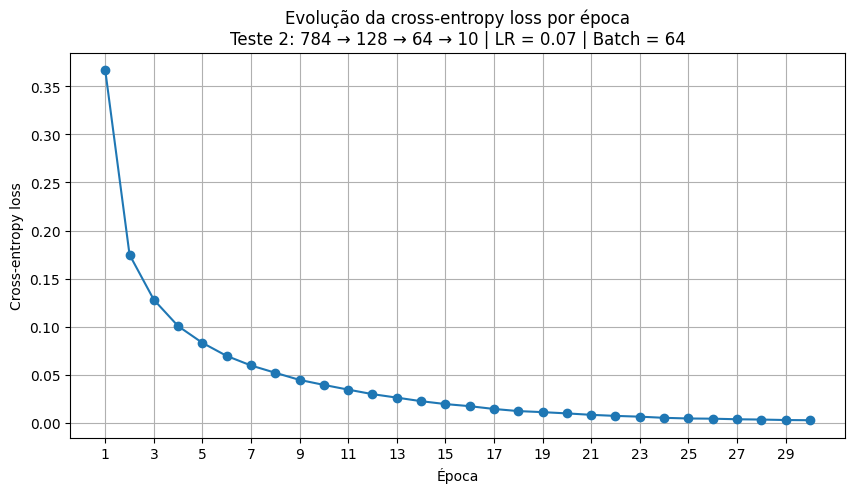

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_2,
    loss_teste_2,
    marker="o"
)

plt.title(
    "Evolução da cross-entropy loss por época\n"
    "Teste 2: 784 → 128 → 64 → 10 | LR = 0.07 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(
    range(1, 31, 2)
)

plt.grid(True)

plt.savefig(
    "../results/teste_2_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 2

No segundo teste, o learning rate foi reduzido de **0.10** para **0.07**
e a quantidade de épocas foi aumentada de **10** para **30**.

O treinamento demorou aproximadamente **1 minuto e 8 segundos**.

A melhor acurácia de teste foi registrada na época 25:

```text
98,08%
```

A acurácia final foi 98,04%. Comparando com o baseline, houve um ganho máximo de 98,08% - 97,94% = 0,14 ponto percentual.

A loss caiu de 0,0286 no final do baseline para 0,0029 no final
do segundo experimento.

Essa queda mostra que o modelo ficou mais confiante em suas previsões.

Por outro lado, a acurácia de treino atingiu 100,00%, enquanto a
acurácia de teste permaneceu próxima de 98,00%. Isso sugere um leve
início de overfitting.

O aumento de épocas trouxe uma melhora pequena na acurácia de teste,
mas aumentou consideravelmente o tempo de treinamento.

Por isso, vou alterar um parâmetro por vez para entender melhor. Vou voltar um passo e diminuir para 20 épocas para ver o resultado, mesmo que de para ver muito claro no gráfico que é a partir daí que começa os 100% nos treinamentos. 

# Terceiro teste: aumento do learning rate

No segundo teste, foi utilizado um learning rate de **0.07**. Neste
experimento, o valor foi aumentado para **0.11**.

A arquitetura, o batch size, a quantidade de épocas e a seed foram
mantidos iguais. Dessa forma, a comparação permite observar de forma
mais clara o efeito da alteração do learning rate.

## Parâmetros utilizados

| Parâmetro | Valor |
|---|---:|
| Arquitetura | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 |
| Função de ativação | ReLU |
| Ativação da saída | Softmax |
| Função de erro | Cross-entropy loss |
| Otimizador | SGD |
| Learning rate | 0.11 |
| Batch size | 64 |
| Épocas | 30 |
| Seed | 42 |
| Tempo de treinamento | 1 minuto e 10 segundos |

## Alteração em relação ao teste anterior

| Parâmetro | Teste 2 | Teste 3 |
|---|---:|---:|
| Learning rate | 0.08 | 0.11 |

Todos os demais parâmetros foram mantidos iguais.

In [18]:
epocas_teste_3 = list(range(1, 31))

loss_teste_3 = [
    0.3207,
    0.1417,
    0.1015,
    0.0788,
    0.0640,
    0.0528,
    0.0442,
    0.0374,
    0.0306,
    0.0258,
    0.0215,
    0.0178,
    0.0143,
    0.0120,
    0.0097,
    0.0074,
    0.0060,
    0.0050,
    0.0044,
    0.0035,
    0.0029,
    0.0025,
    0.0022,
    0.0019,
    0.0017,
    0.0016,
    0.0015,
    0.0014,
    0.0012,
    0.0012
]

acuracia_treino_teste_3 = [
    94.68,
    96.51,
    97.45,
    98.16,
    98.52,
    98.71,
    98.79,
    98.71,
    99.07,
    99.47,
    99.55,
    99.70,
    99.63,
    99.37,
    99.81,
    99.96,
    99.95,
    99.96,
    99.79,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00
]

acuracia_teste_teste_3 = [
    94.73,
    95.88,
    96.81,
    97.29,
    97.61,
    97.41,
    97.53,
    97.24,
    97.60,
    97.88,
    97.94,
    97.86,
    97.57,
    97.37,
    98.00,
    98.07,
    98.09,
    98.03,
    97.69,
    98.16,
    98.07,
    98.14,
    98.10,
    98.15,
    98.17,
    98.16,
    98.17,
    98.13,
    98.12,
    98.14
]

## Gráfico da acurácia

O gráfico mostra a evolução da acurácia de treino e da acurácia de
teste ao longo das 30 épocas.

A acurácia de teste começou em **94,73%** e atingiu seu maior valor nas
épocas 25 e 27:

```text
98,17%
```
A partir da vigésima época, a acurácia de teste permaneceu próxima de
98%, apresentando apenas pequenas oscilações.

A acurácia de treino atingiu 100,00% na vigésima época e permaneceu
nesse nível até o final.

Isso mostra que o modelo aprendeu completamente os exemplos de treino.
Entretanto, como a acurácia de teste se estabilizou próxima de 98%, os
ganhos de generalização passaram a ser pequenos.

Ou seja, devemos alterar outros parâmetros e dessa forma, está adequada!

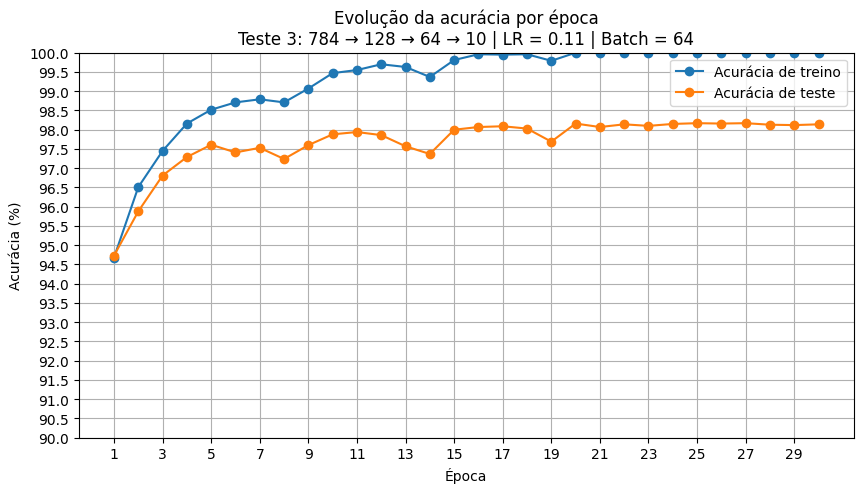

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_3,
    acuracia_treino_teste_3,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas_teste_3,
    acuracia_teste_teste_3,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Teste 3: 784 → 128 → 64 → 10 | LR = 0.11 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    90,
    100
)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/teste_3_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

# Gráfico de loss

A loss caiu de **0,3207** na primeira época para **0,0012** na trigésima
época.

Assim como nos testes anteriores, a maior queda aconteceu nas primeiras
épocas. Depois disso, a curva passou a diminuir de forma mais gradual.

Comparando com o segundo teste, a loss final foi menor:

```text
Teste 2 → 0,0029
Teste 3 → 0,0012
```

Isso indica que o aumento do learning rate permitiu ao modelo ajustar
os pesos de forma mais rápida e produzir previsões mais confiantes.



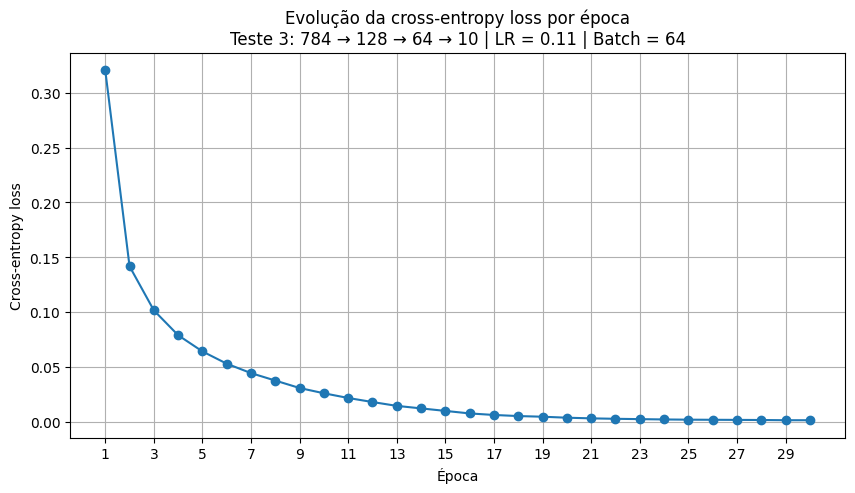

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_3,
    loss_teste_3,
    marker="o"
)

plt.title(
    "Evolução da cross-entropy loss por época\n"
    "Teste 3: 784 → 128 → 64 → 10 | LR = 0.11 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(
    range(1, 31, 2)
)

plt.grid(True)

plt.savefig(
    "../results/teste_3_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 3

No terceiro teste, o learning rate foi aumentado de **0.07** para
**0.11**.

Os demais parâmetros foram mantidos iguais ao segundo teste:

```text
Arquitetura: 784 → 128 → 64 → 10
Batch size: 64
Épocas: 30
Seed: 42
```
O treinamento demorou aproximadamente 1 minuto e 10 segundos.

A maior acurácia de teste foi registrada nas épocas 25 e 27, estando em 98,17%. 
Já a acurácia final foi 98,14%. 

Comparando com o segundo teste, houve uma pequena melhora, com 98,17% - 98,08% = 0,09 ponto 
percentual de melhora.

A loss final também caiu entre o teste 2 para 3: Teste 2 → 0,0029 --- Teste 3 → 0,0012

O learning rate de 0.11 apresentou um desempenho ligeiramente
superior ao learning rate de 0.07.

Por outro lado, a acurácia de treino atingiu 100,00% a partir da
vigésima época, enquanto a acurácia de teste permaneceu próxima de 98%.

O próximo passo será testar um learning rate um pouco maior para
verificar até qual ponto o modelo continua melhorando antes de começar
a ficar instável. Outro ponto importante é que não devemos baixar as épocas,
já que os melhores testes aconteceram nas épocas 25 e 27.


# Gráfico comparativo entre os testes 2 e 3

Agora vale criar um gráfico colocando as duas curvas de acurácia de teste lado a lado.


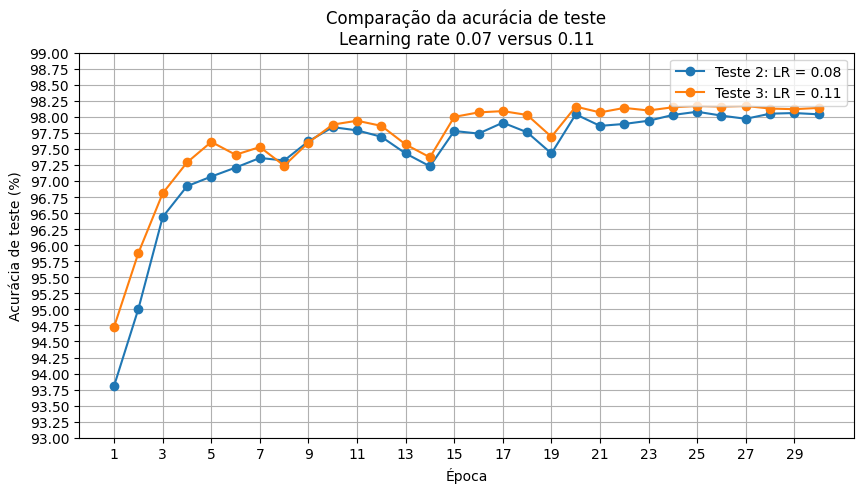

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_2,
    acuracia_teste_teste_2,
    marker="o",
    label="Teste 2: LR = 0.08"
)

plt.plot(
    epocas_teste_3,
    acuracia_teste_teste_3,
    marker="o",
    label="Teste 3: LR = 0.11"
)

plt.title(
    "Comparação da acurácia de teste\n"
    "Learning rate 0.07 versus 0.11"
)

plt.xlabel("Época")
plt.ylabel("Acurácia de teste (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    93,
    99
)

plt.yticks(
    np.arange(93, 99.25, 0.25)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/comparacao_lr_008_lr_011_acuracia.png",
    bbox_inches="tight"
)

plt.show()

O gráfico compara os resultados do segundo e do terceiro teste.

O terceiro teste, com learning rate de **0.11**, apresentou uma evolução
mais rápida nas primeiras épocas e atingiu uma acurácia máxima
ligeiramente maior.

```text
Teste 2 | LR = 0.08 → melhor acurácia: 98,08%
Teste 3 | LR = 0.11 → melhor acurácia: 98,17%
```
A diferença foi pequena, mas mostra que o modelo ainda suportou um
learning rate um pouco maior sem perder estabilidade.

# Quarto teste: aumento do learning rate para 0.15

## Objetivo

No quarto teste, o learning rate foi aumentado de **0.11** para **0.15**.

O objetivo foi verificar se uma taxa de aprendizado maior permitiria
reduzir a loss mais rapidamente e melhorar a acurácia de teste.

A arquitetura, o batch size, a quantidade de épocas e a seed foram
mantidos iguais ao experimento anterior. Dessa forma, a comparação
permite analisar diretamente o impacto do learning rate.

## Parâmetros utilizados

| Parâmetro | Valor |
|---|---:|
| Arquitetura | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 |
| Função de ativação | ReLU |
| Ativação da saída | Softmax |
| Função de erro | Cross-entropy loss |
| Otimizador | SGD |
| Learning rate | 0.15 |
| Batch size | 64 |
| Épocas | 30 |
| Seed | 42 |
| Tempo de treinamento | 1 minuto e 5 segundos |

## Alteração em relação ao teste anterior

| Parâmetro | Teste 3 | Teste 4 |
|---|---:|---:|
| Learning rate | 0.11 | 0.15 |

Todos os demais parâmetros foram mantidos iguais.

In [22]:
epocas_teste_4 = list(range(1, 31))

loss_teste_4 = [
    0.2977,
    0.1238,
    0.0892,
    0.0684,
    0.0557,
    0.0440,
    0.0360,
    0.0302,
    0.0234,
    0.0197,
    0.0152,
    0.0119,
    0.0094,
    0.0066,
    0.0048,
    0.0040,
    0.0030,
    0.0024,
    0.0021,
    0.0017,
    0.0013,
    0.0012,
    0.0011,
    0.0010,
    0.0009,
    0.0008,
    0.0007,
    0.0007,
    0.0006,
    0.0006
]

acuracia_treino_teste_4 = [
    94.98,
    97.00,
    97.84,
    98.39,
    98.82,
    98.97,
    98.93,
    98.88,
    99.40,
    99.67,
    99.64,
    99.77,
    99.69,
    99.92,
    99.94,
    99.98,
    99.96,
    99.99,
    99.97,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00
]

acuracia_teste_teste_4 = [
    95.03,
    96.17,
    96.98,
    97.20,
    97.68,
    97.65,
    97.37,
    97.53,
    97.82,
    97.94,
    98.03,
    97.88,
    97.59,
    98.00,
    98.00,
    98.11,
    98.04,
    98.05,
    97.96,
    98.09,
    98.06,
    98.10,
    98.10,
    98.12,
    98.14,
    98.12,
    98.15,
    98.15,
    98.13,
    98.12
]

## Gráfico da acurácia

Nesta célula foi criado um gráfico de linha para acompanhar a evolução
da acurácia de treino e de teste durante as 30 épocas.

O quarto teste demorou aproximadamente **1 minuto e 5 segundos**.

A curva de treino atingiu 100% a partir da vigésima época. Já a curva
de teste permaneceu próxima de 98%, com pequenas oscilações.

Isso indica que a rede continuou aprendendo os exemplos de treino, mas
os ganhos em imagens novas ficaram cada vez menores.

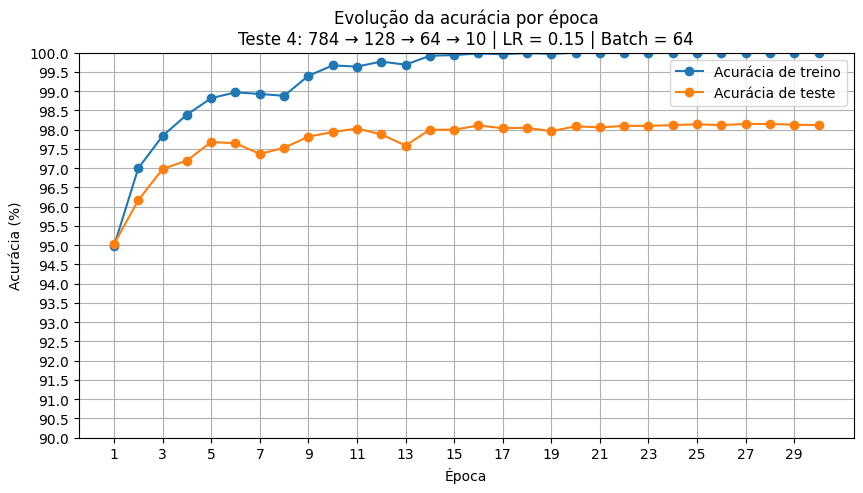

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_4,
    acuracia_treino_teste_4,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas_teste_4,
    acuracia_teste_teste_4,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Teste 4: 784 → 128 → 64 → 10 | LR = 0.15 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    90,
    100
)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/teste_4_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

# Gráfico de loss

A curva de loss apresentou uma queda consistente ao longo das 30
épocas.

A loss começou em **0,2977** e terminou em **0,0006**.

Comparando com o experimento anterior, o learning rate maior permitiu
que o erro diminuísse ainda mais rapidamente.

Entretanto, a redução da loss não trouxe uma melhora relevante na
acurácia de teste.

Isso mostra que o modelo ficou mais confiante nas respostas corretas,
mas não aumentou significativamente a quantidade de classificações
corretas em imagens novas.

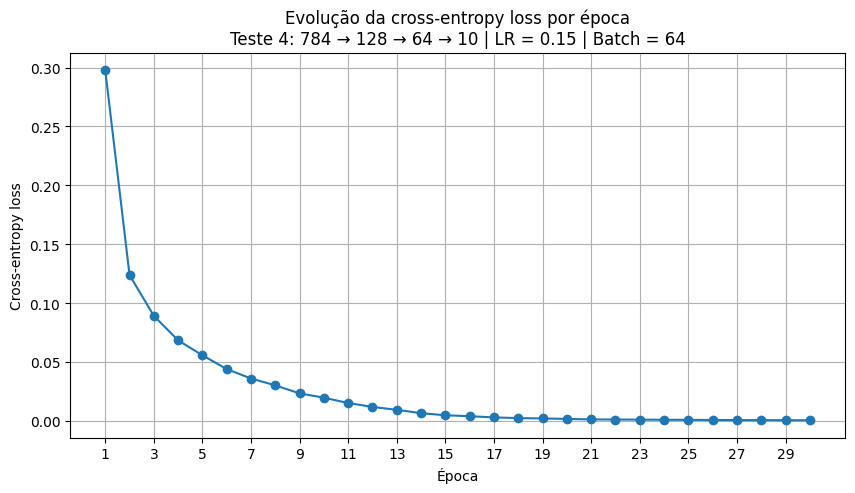

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_4,
    loss_teste_4,
    marker="o"
)

plt.title(
    "Evolução da cross-entropy loss por época\n"
    "Teste 4: 784 → 128 → 64 → 10 | LR = 0.15 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(
    range(1, 31, 2)
)

plt.grid(True)

plt.savefig(
    "../results/teste_4_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 4

No quarto teste, o learning rate foi aumentado de **0.11** para
**0.15**.

Os demais parâmetros foram mantidos iguais:

```text
Arquitetura: 784 → 128 → 64 → 10
Batch size: 64
Épocas: 30
Seed: 42
```
O treinamento demorou aproximadamente 1 minuto e 5 segundos.

A maior acurácia de teste foi registrada nas épocas 27 e 28, com 98,15%. 
Já a acurácia final foi em 98,12%.
A loss final foi 0,0006

Se compararmos com o teste passado, a acurácia piorou, mesmo o loss melhorando:
Teste 3 | LR = 0.11 → melhor acurácia: 98,17%
Teste 4 | LR = 0.15 → melhor acurácia: 98,15%

Isso mostra que aumentar o learning rate permitiu que o modelo ficasse
mais confiante em suas previsões, mas não aumentou sua capacidade de
generalização.

Além disso, a acurácia de treino atingiu 100,00%, enquanto a
acurácia de teste permaneceu próxima de 98,00%.

Esse resultado reforça a presença de um leve overfitting e indica que
o modelo está próximo do limite de desempenho dessa configuração.

# Comparação entre learning rates

Nesta análise, foram comparadas três taxas de aprendizado:

```text
Teste 2 → learning rate = 0.08
Teste 3 → learning rate = 0.11
Teste 4 → learning rate = 0.15
```

Os demais parâmetros foram mantidos iguais.

O objetivo é verificar como o tamanho do passo utilizado pelo SGD afeta
a velocidade de aprendizado e a acurácia de teste.

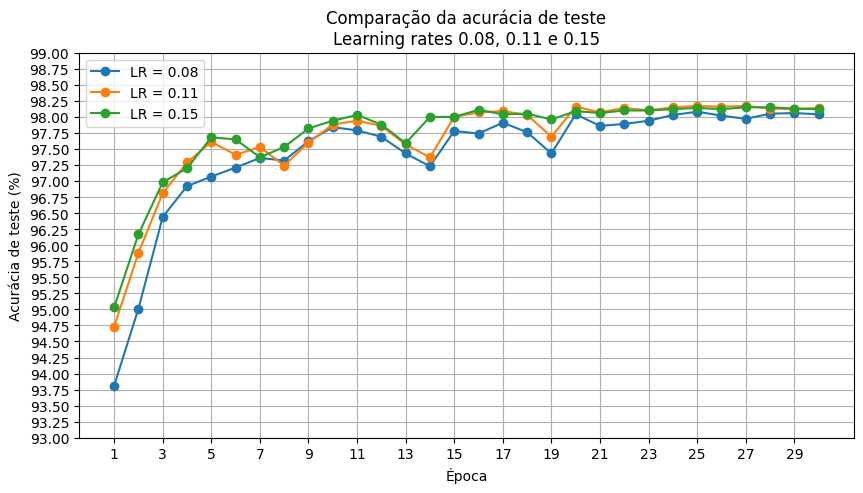

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_2,
    acuracia_teste_teste_2,
    marker="o",
    label="LR = 0.08"
)

plt.plot(
    epocas_teste_3,
    acuracia_teste_teste_3,
    marker="o",
    label="LR = 0.11"
)

plt.plot(
    epocas_teste_4,
    acuracia_teste_teste_4,
    marker="o",
    label="LR = 0.15"
)

plt.title(
    "Comparação da acurácia de teste\n"
    "Learning rates 0.08, 0.11 e 0.15"
)

plt.xlabel("Época")
plt.ylabel("Acurácia de teste (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    93,
    99
)

plt.yticks(
    np.arange(93, 99.25, 0.25)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/comparacao_learning_rates_acuracia.png",
    bbox_inches="tight"
)

plt.show()

## Análise comparativa

O aumento do learning rate acelerou a redução da loss nas primeiras
épocas.

Entretanto, a acurácia máxima de teste não apresentou uma melhoria
proporcional.

| Teste | Learning rate | Melhor acurácia de teste | Loss final |
|---|---:|---:|---:|
| Teste 2 | 0.08 | 98,08% | 0,0029 |
| Teste 3 | 0.11 | 98,17% | 0,0012 |
| Teste 4 | 0.15 | 98,15% | 0,0006 |

O melhor resultado de acurácia foi obtido no terceiro teste, com
learning rate de **0.11**.

O quarto teste apresentou a menor loss, mas não atingiu a maior
acurácia de teste.

Isso mostra que a loss e a acurácia são métricas relacionadas, mas não
são equivalentes.

Agora, já que "alcançamos" a melhor acurácia só mudando o aprendizado, vamos alterar o tamanho de imagem que juntamos para testar se isso altera demais o acurácia.

# Quinto teste: redução do batch size para 32

Nos testes anteriores, foi utilizado um batch size de **64**. Neste
experimento, o valor foi reduzido para **32**.

O learning rate foi mantido em **0.11**, pois essa taxa apresentou o
melhor desempenho entre os learning rates testados anteriormente.

A arquitetura, a quantidade de épocas e a seed também foram mantidas
iguais. Dessa forma, a comparação permite analisar diretamente o
efeito do batch size.

## Parâmetros utilizados

| Parâmetro | Valor |
|---|---:|
| Arquitetura | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 |
| Função de ativação | ReLU |
| Ativação da saída | Softmax |
| Função de erro | Cross-entropy loss |
| Otimizador | SGD |
| Learning rate | 0.11 |
| Batch size | 32 |
| Épocas | 30 |
| Seed | 42 |
| Tempo de treinamento | 1 minuto |

## Alteração em relação ao teste de referência

| Parâmetro | Teste 3 | Teste 5 |
|---|---:|---:|
| Learning rate | 0.11 | 0.11 |
| Batch size | 64 | 32 |

Todos os demais parâmetros foram mantidos iguais.

## Interpretação da alteração

Com batch size de 64, cada atualização dos pesos utiliza um grupo de
64 imagens.

Com batch size de 32, cada atualização utiliza apenas 32 imagens.

Isso significa que a rede atualiza os pesos mais vezes durante cada
época. O objetivo foi verificar se essas atualizações mais frequentes
ajudariam o modelo a melhorar sua capacidade de generalização.

In [26]:
epocas_teste_5 = list(range(1, 31))

loss_teste_5 = [
    0.2474,
    0.1043,
    0.0748,
    0.0565,
    0.0439,
    0.0353,
    0.0285,
    0.0227,
    0.0171,
    0.0153,
    0.0098,
    0.0073,
    0.0047,
    0.0022,
    0.0014,
    0.0009,
    0.0006,
    0.0005,
    0.0004,
    0.0004,
    0.0003,
    0.0003,
    0.0003,
    0.0002,
    0.0002,
    0.0002,
    0.0002,
    0.0002,
    0.0002,
    0.0002
]

acuracia_treino_teste_5 = [
    96.64,
    97.43,
    98.27,
    98.74,
    99.21,
    98.82,
    99.37,
    99.41,
    99.57,
    99.61,
    99.76,
    99.82,
    99.95,
    99.98,
    99.99,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00
]

acuracia_teste_teste_5 = [
    96.31,
    96.57,
    97.30,
    97.52,
    97.99,
    97.40,
    97.68,
    97.79,
    97.92,
    97.98,
    98.16,
    97.99,
    98.11,
    98.28,
    98.30,
    98.34,
    98.27,
    98.33,
    98.33,
    98.30,
    98.28,
    98.27,
    98.28,
    98.27,
    98.24,
    98.26,
    98.25,
    98.26,
    98.21,
    98.22
]

## Gráfico da acurácia

Nesta célula foi criado um gráfico de linha para acompanhar a evolução
da acurácia de treino e de teste durante as 30 épocas.

O treinamento demorou aproximadamente **1 minuto**.

A melhor acurácia de teste foi registrada na época 16:

```text
98,34%
```
Depois disso, a acurácia de treino permaneceu em 100%, enquanto a
acurácia de teste apresentou uma pequena queda gradual.

Isso mostra que continuar treinando o modelo depois da época 16 não
trouxe ganhos reais de generalização.

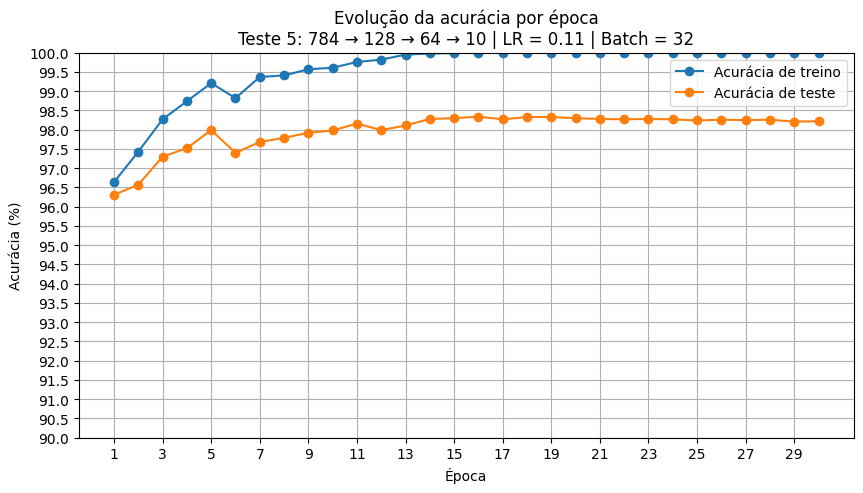

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_5,
    acuracia_treino_teste_5,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas_teste_5,
    acuracia_teste_teste_5,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Teste 5: 784 → 128 → 64 → 10 | LR = 0.11 | Batch = 32"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    90,
    100
)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/teste_5_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

# Gráfico de loss

A loss apresentou uma queda consistente ao longo do treinamento.

O valor começou em **0,2474** e terminou em **0,0002**.

A curva mostra que o modelo ficou progressivamente mais confiante em
suas previsões.

Entretanto, após a época 16, a loss continuou diminuindo enquanto a
acurácia de teste deixou de melhorar.

Isso indica que o modelo passou a ajustar cada vez melhor os exemplos
de treino, mas sem aumentar sua capacidade de acertar imagens novas.

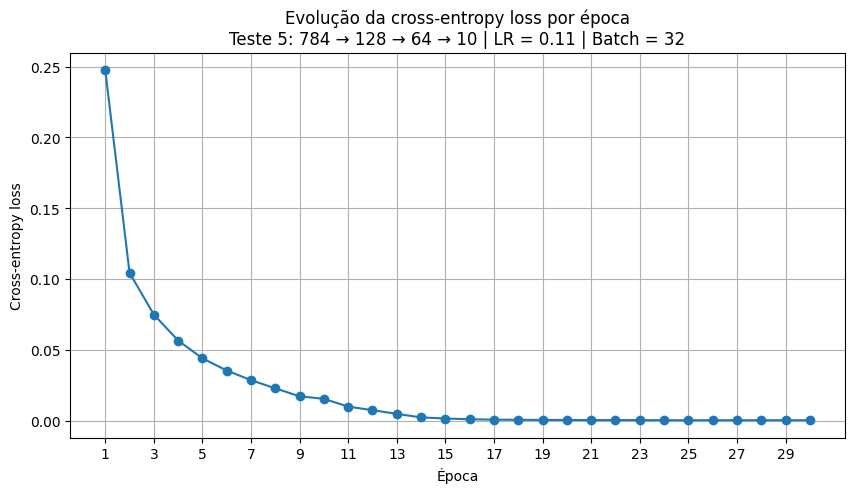

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_5,
    loss_teste_5,
    marker="o"
)

plt.title(
    "Evolução da cross-entropy loss por época\n"
    "Teste 5: 784 → 128 → 64 → 10 | LR = 0.11 | Batch = 32"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(
    range(1, 31, 2)
)

plt.grid(True)

plt.savefig(
    "../results/teste_5_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 5

No quinto teste, o batch size foi reduzido de **64** para **32**.

Os demais parâmetros foram mantidos iguais ao terceiro teste:

```text
Arquitetura: 784 → 128 → 64 → 10
Learning rate: 0.11
Épocas: 30
Seed: 42
```

O treinamento demorou aproximadamente 1 minuto.

A maior acurácia de teste foi registrada na época 16, com o valor em 98,34%

Esse foi o melhor resultado obtido até agora.

Comparando com o terceiro teste, ficou bem melhor:
Teste 3 | Batch size = 64 → melhor acurácia: 98,17%
Teste 5 | Batch size = 32 → melhor acurácia: 98,34%

A melhora foi de 0,17 pontos percentuais.

A redução do batch size fez com que os pesos fossem atualizados mais
vezes durante cada época. Isso permitiu que o modelo atingisse uma
acurácia maior em menos épocas.

Entretanto, depois da época 16, a acurácia de treino permaneceu em
100%, enquanto a acurácia de teste começou a cair levemente.

Isso mostra um início mais claro de overfitting.

Então um jeito de driblar isso é diminuindo a épocas de 30 para 20, onde os testes estão indo melhor, além de diminuir ainda mais o batch_size, já que o teste foi bem satisfatório.

# Comparação entre batch sizes

Nesta análise, foram comparados dois tamanhos de mini-batch:

```text
Teste 3 → batch size = 64
Teste 5 → batch size = 32
```

Os dois testes utilizaram:
```text
Learning rate = 0.11
Épocas = 30
Arquitetura = 784 → 128 → 64 → 10
Seed = 42
```

O objetivo foi analisar se atualizações mais frequentes dos pesos
melhorariam a acurácia do modelo.

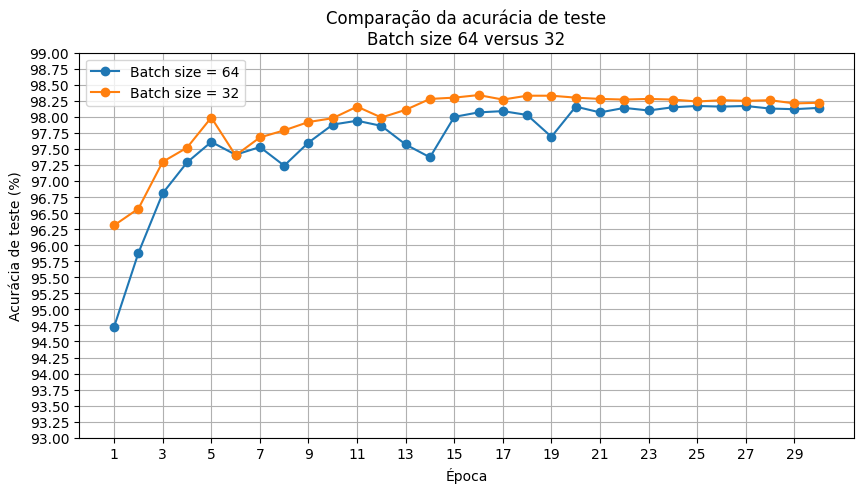

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_3,
    acuracia_teste_teste_3,
    marker="o",
    label="Batch size = 64"
)

plt.plot(
    epocas_teste_5,
    acuracia_teste_teste_5,
    marker="o",
    label="Batch size = 32"
)

plt.title(
    "Comparação da acurácia de teste\n"
    "Batch size 64 versus 32"
)

plt.xlabel("Época")
plt.ylabel("Acurácia de teste (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    93,
    99
)

plt.yticks(
    np.arange(93, 99.25, 0.25)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/comparacao_batch_64_batch_32_acuracia.png",
    bbox_inches="tight"
)

plt.show()

## Análise comparativa

O batch size de **32** apresentou uma evolução mais rápida e atingiu
uma acurácia máxima maior.

| Teste | Batch size | Melhor acurácia de teste | Época da melhor acurácia |
|---|---:|---:|---:|
| Teste 3 | 64 | 98,17% | 25 e 27 |
| Teste 5 | 32 | 98,34% | 16 |

A redução do batch size aumentou a frequência de atualização dos pesos
e permitiu que o modelo chegasse ao seu melhor resultado mais cedo.

Entretanto, o gráfico também mostra que continuar o treinamento após a
época 16 trouxe poucos benefícios e começou a reduzir levemente a
acurácia de teste.

Vamos colocar época com valor de 20 e batch_size em 16 para ver os resultados.

# Sexto teste: redução do batch size para 16

A quantidade de épocas e de batch_size foi reduzida de 30 para 20 e 32 para 16, pois
o teste anterior mostrou que o modelo já atingia seu melhor resultado
antes da vigésima época.

## Parâmetros utilizados

| Parâmetro | Valor |
|---|---:|
| Arquitetura | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 |
| Função de ativação | ReLU |
| Ativação da saída | Softmax |
| Função de erro | Cross-entropy loss |
| Otimizador | SGD |
| Learning rate | 0.11 |
| Batch size | 16 |
| Épocas | 20 |
| Seed | 42 |
| Tempo de treinamento | 52 segundos |

## Alterações em relação ao teste anterior

| Parâmetro | Teste 5 | Teste 6 |
|---|---:|---:|
| Batch size | 32 | 16 |
| Épocas | 30 | 20 |

O learning rate, a arquitetura e a seed foram mantidos iguais.

## Interpretação da alteração

A redução do batch size faz com que os pesos sejam atualizados mais
vezes durante cada época.

Entretanto, cada atualização passa a considerar um grupo menor de
imagens. Isso pode tornar o gradiente mais sensível às particularidades
de cada mini-batch e causar oscilações durante o treinamento.

In [31]:
epocas_teste_6 = list(range(1, 21))

loss_teste_6 = [
    0.2313,
    0.1052,
    0.0768,
    0.0616,
    0.0493,
    0.0430,
    0.0327,
    0.0331,
    0.0259,
    0.0285,
    0.0243,
    0.0213,
    0.0177,
    0.0190,
    0.0140,
    0.0188,
    0.0126,
    0.0130,
    0.0126,
    0.0182
]

acuracia_treino_teste_6 = [
    96.72,
    97.81,
    98.28,
    98.39,
    98.91,
    98.99,
    98.61,
    98.62,
    99.18,
    99.12,
    99.14,
    99.56,
    99.37,
    99.30,
    99.57,
    99.57,
    99.77,
    99.69,
    99.50,
    99.47
]

acuracia_teste_teste_6 = [
    96.37,
    97.14,
    97.36,
    97.32,
    97.81,
    97.69,
    97.22,
    97.14,
    97.75,
    97.50,
    97.74,
    97.79,
    97.70,
    97.52,
    97.66,
    97.87,
    98.11,
    97.93,
    97.74,
    97.74
]

## Gráfico da acurácia

Nesta célula foi criado um gráfico de linha para acompanhar a evolução
da acurácia de treino e de teste durante as 20 épocas.

O treinamento demorou aproximadamente **52 segundos**.

A maior acurácia de teste foi registrada na época 17:

```text
98,11%
```

Apesar de alcançar um bom resultado, a curva apresentou oscilações mais
fortes do que no experimento com batch size de 32.

Isso indica que reduzir demais o tamanho do mini-batch não trouxe uma
melhora consistente.

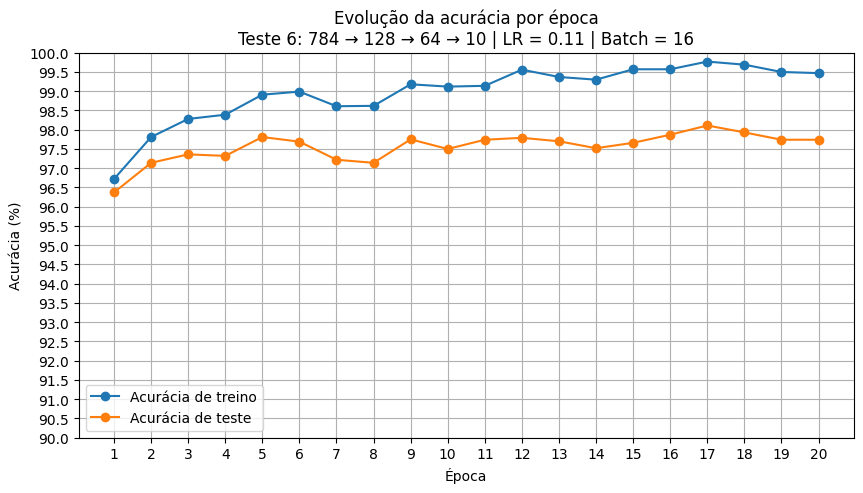

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_6,
    acuracia_treino_teste_6,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas_teste_6,
    acuracia_teste_teste_6,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Teste 6: 784 → 128 → 64 → 10 | LR = 0.11 | Batch = 16"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(
    range(1, 21)
)

plt.ylim(
    90,
    100
)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/teste_6_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

# Gráfico de loss

A loss começou em **0,2313** e terminou em **0,0182**.

Diferentemente dos testes anteriores, a curva não apresentou uma queda
contínua.

Em algumas épocas, a loss voltou a subir:

```text
Época 7  → 0,0327
Época 8  → 0,0331

Época 13 → 0,0177
Época 14 → 0,0190

Época 19 → 0,0126
Época 20 → 0,0182
```

Isso mostra que o treinamento ficou mais instável.

Com batch size de 16, cada atualização dos pesos utiliza poucas
imagens. Mantendo o learning rate em 0.11, os passos de atualização
ficaram agressivos para esse tamanho de lote.

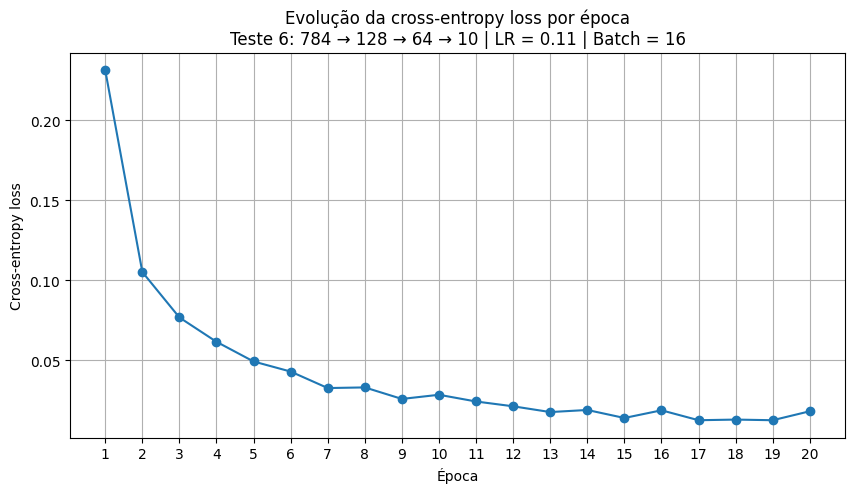

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_6,
    loss_teste_6,
    marker="o"
)

plt.title(
    "Evolução da cross-entropy loss por época\n"
    "Teste 6: 784 → 128 → 64 → 10 | LR = 0.11 | Batch = 16"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(
    range(1, 21)
)

plt.grid(True)

plt.savefig(
    "../results/teste_6_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 6

No sexto teste, o batch size foi reduzido de **32** para **16** e a
quantidade de épocas foi reduzida de **30** para **20**.

O treinamento demorou aproximadamente **52 segundos**.

A maior acurácia de teste foi registrada na época 17:

```text
98,11%
```

Esse resultado foi inferior ao melhor resultado do teste anterior:
Teste 5 | Batch size = 32 → melhor acurácia: 98,34%
Teste 6 | Batch size = 16 → melhor acurácia: 98,11%

Além disso, a loss apresentou oscilações e voltou a subir em algumas
épocas.

Isso mostra que reduzir o batch size aumentou demais a frequência e a
variabilidade das atualizações.

O batch size de 32 apresentou um equilíbrio melhor entre velocidade,
estabilidade e acurácia.

Portanto, o batch size de 32 será mantido nos próximos testes.

Bom, não vou perder tempo fazendo o gráfico comparativo, mas está claro:
batch_size diminuindo não está ajudando, vamos alterar a rede, dobrando
a rede. 

# Sétimo teste: aumento da arquitetura da rede

## Objetivo

No sétimo teste, o objetivo foi analisar se uma rede neural com mais
neurônios nas camadas ocultas conseguiria melhorar a acurácia de teste.

Nos primeiros experimentos, foi utilizada a seguinte arquitetura:

```text
784 → 128 → 64 → 1
```
Neste teste, a arquitetura foi ampliada para:

```text
784 → 256 → 128 → 10
```

O learning rate foi mantido em 0.11 e o batch size foi mantido em
32, pois esses valores apresentaram o melhor equilíbrio nos testes
anteriores.

A quantidade de épocas foi reduzida para 20, porque os experimentos
anteriores mostraram que o modelo já alcançava seus melhores resultados
antes da vigésima época.

| Parâmetro | Valor |
|---|---:|
| Arquitetura | 784 → 256 → 128 → 10 |
| Camadas ocultas | 2 |
| Função de ativação | ReLU |
| Ativação da saída | Softmax |
| Função de erro | Cross-entropy loss |
| Otimizador | SGD |
| Learning rate | 0.11 |
| Batch size | 32 |
| Épocas | 20 |
| Seed | 42 |
| Tempo de treinamento | 49 segundos |

## Interpretação da arquitetura

Cada imagem continua sendo transformada em um vetor com 784 valores.

A nova arquitetura possui mais neurônios nas camadas ocultas.

O objetivo foi aumentar a capacidade da rede de identificar padrões
mais detalhados nas imagens.


In [34]:
epocas_teste_7 = list(range(1, 21))

loss_teste_7 = [
    0.2447,
    0.0999,
    0.0685,
    0.0498,
    0.0381,
    0.0273,
    0.0202,
    0.0153,
    0.0097,
    0.0071,
    0.0044,
    0.0027,
    0.0017,
    0.0011,
    0.0010,
    0.0008,
    0.0007,
    0.0006,
    0.0005,
    0.0005
]

acuracia_treino_teste_7 = [
    96.73,
    98.03,
    98.28,
    98.73,
    99.33,
    99.27,
    99.53,
    99.80,
    99.75,
    99.88,
    99.98,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00,
    100.00
]

acuracia_teste_teste_7 = [
    96.53,
    97.24,
    97.09,
    97.44,
    98.16,
    97.79,
    98.03,
    98.19,
    98.02,
    98.10,
    98.21,
    98.35,
    98.40,
    98.37,
    98.33,
    98.40,
    98.34,
    98.37,
    98.40,
    98.37
]

## Gráfico da acurácia

Nesta célula foi criado um gráfico de linha para acompanhar a evolução
da acurácia de treino e da acurácia de teste durante as 20 épocas.

O treinamento demorou aproximadamente **49 segundos**.

A maior acurácia de teste foi:

```text
98,40%
```

Esse resultado apareceu nas épocas 13, 16 e 19.

A rede atingiu 100% de acurácia de treino na época 12. A partir desse
momento, a acurácia de teste permaneceu próxima de 98,40%, com pequenas
oscilações.

Isso mostra que a nova arquitetura aumentou levemente a capacidade de
generalização do modelo.

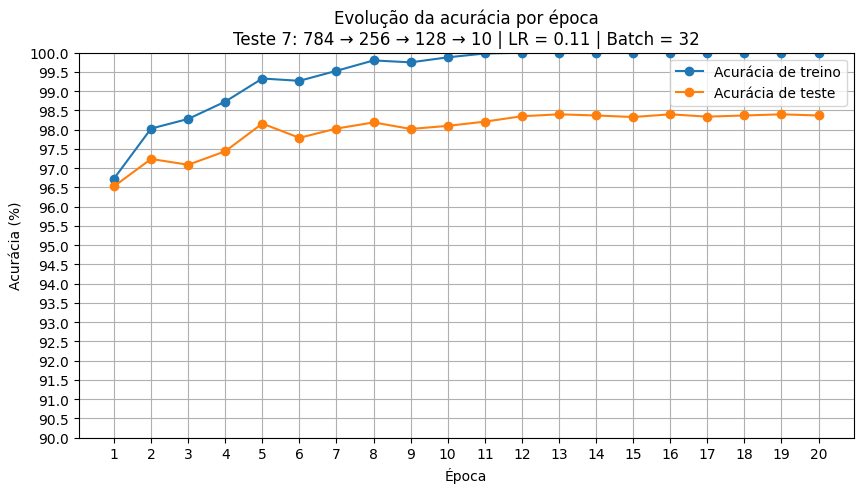

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_7,
    acuracia_treino_teste_7,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas_teste_7,
    acuracia_teste_teste_7,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Teste 7: 784 → 256 → 128 → 10 | LR = 0.11 | Batch = 32"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(
    range(1, 21)
)

plt.ylim(
    90,
    100
)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/teste_7_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

# Gráfico de loss

A loss começou em **0,2447** e terminou em **0,0005**.

A curva apresentou uma queda consistente durante o treinamento.

Nas primeiras épocas, a redução foi mais intensa. Depois disso, a curva
passou a diminuir de forma mais gradual.

A loss continuou caindo mesmo depois de a acurácia de teste se
estabilizar próxima de 98,40%.

Isso mostra que a rede continuou ficando mais confiante em suas
previsões, mesmo quando a quantidade total de acertos em imagens novas
já não aumentava de forma relevante.

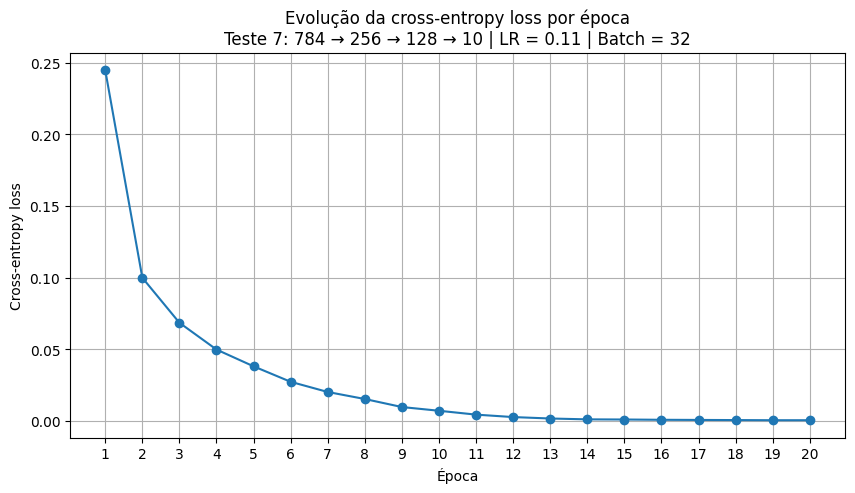

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_7,
    loss_teste_7,
    marker="o"
)

plt.title(
    "Evolução da cross-entropy loss por época\n"
    "Teste 7: 784 → 256 → 128 → 10 | LR = 0.11 | Batch = 32"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(
    range(1, 21)
)

plt.grid(True)

plt.savefig(
    "../results/teste_7_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 7

No sétimo teste, a arquitetura foi ampliada:

```text
Teste 5 → 784 → 128 → 64 → 10
Teste 7 → 784 → 256 → 128 → 10
```

O learning rate foi mantido em 0.11 e o batch size foi mantido em
32.

A quantidade de épocas foi reduzida para 20, pois os experimentos
anteriores já mostravam que o melhor desempenho normalmente era
atingido antes desse ponto.

O treinamento demorou aproximadamente 49 segundos.

A melhor acurácia de teste foi em 98,40%. Esse valor foi registrado nas
épocas 13, 16 e 19.

Comparando com o melhor resultado anterior:
Teste 5 | Arquitetura 784 → 128 → 64 → 10 → 98,34%
Teste 7 | Arquitetura 784 → 256 → 128 → 10 → 98,40%

A melhora foi de só 0,06 em percentual. 

Mesmo sendo uma melhoria pequena, o novo modelo atingiu o melhor
resultado em menos tempo:
Teste 5 → 60 segundos
Teste 7 → 49 segundos

A nova arquitetura apresentou um equilíbrio melhor entre desempenho e
tempo de treinamento.

Entretanto, a acurácia de treino atingiu 100% na época 12, enquanto a
acurácia de teste permaneceu próxima de 98,40%.

Isso mostra que treinar por muitas épocas adicionais provavelmente
traria poucos ganhos reais.


# Comparação entre arquiteturas

Nesta análise, foram comparadas duas arquiteturas:

```text
Teste 5 → 784 → 128 → 64 → 10
Teste 7 → 784 → 256 → 128 → 10
```
Os dois testes utilizaram Learning rate = 0.11, Batch size = 32 e 
Seed = 42. O objetivo foi analisar se aumentar a quantidade de neurônios nas
camadas ocultas melhoraria a acurácia de teste.

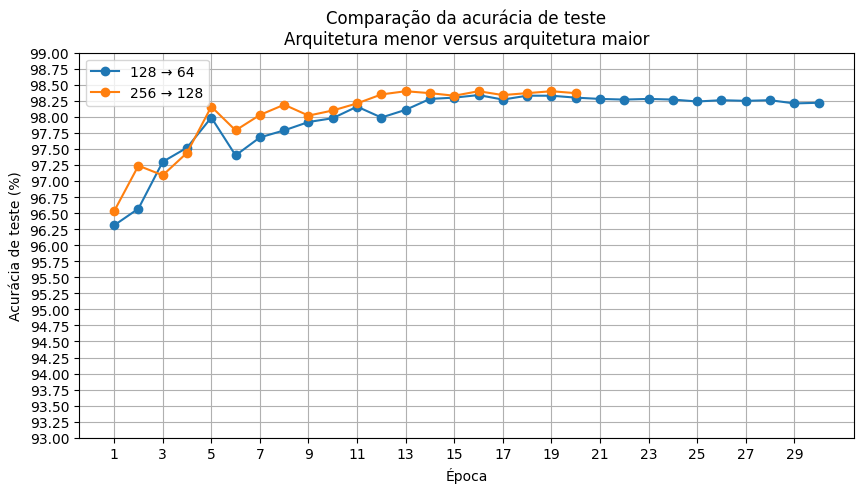

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_5,
    acuracia_teste_teste_5,
    marker="o",
    label="128 → 64"
)

plt.plot(
    epocas_teste_7,
    acuracia_teste_teste_7,
    marker="o",
    label="256 → 128"
)

plt.title(
    "Comparação da acurácia de teste\n"
    "Arquitetura menor versus arquitetura maior"
)

plt.xlabel("Época")
plt.ylabel("Acurácia de teste (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    93,
    99
)

plt.yticks(
    np.arange(93, 99.25, 0.25)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/comparacao_arquiteturas_acuracia.png",
    bbox_inches="tight"
)

plt.show()

## Análise comparativa

| Teste | Arquitetura | Melhor acurácia de teste | Primeira época do melhor resultado |
|---|---|---:|---:|
| Teste 5 | 784 → 128 → 64 → 10 | 98,34% | 16 |
| Teste 7 | 784 → 256 → 128 → 10 | **98,40%** | **13** |

A arquitetura maior apresentou uma pequena melhoria na acurácia máxima
de teste.

Além disso, o melhor resultado apareceu mais cedo.

Isso sugere que aumentar a quantidade de neurônios permitiu à rede
identificar padrões mais detalhados sem aumentar significativamente o
tempo de treinamento.

Próximo teste é aumentar a rede novamente e diminuir as épocas, para menor tempo
de treinamento.